# NHL Expected Goals (xG) Model — A Spatio-Temporal Shot Model

This notebook builds a shot-quality ("expected goals") model for NHL shots using
**spatio-temporal features**: where on the ice the shot was taken (space) combined
with when in the game it happened and the score/strength/rebound/rush context at
that moment (time).

Data comes directly from the NHL's public play-by-play API.

**Pipeline:** fetch play-by-play -> extract
shot events, including rebound/rush context -> engineer spatio-temporal features
-> train a gradient-boosted classifier **and** a logistic-regression baseline on
the same train/test split -> compare -> visualize -> rank players/teams by
finishing skill (actual goals vs. expected goals, using out-of-fold predictions).


In [1]:
import sys
sys.path.insert(0, "src")

import datetime
from fetch_data import fetch_shots_for_date_range, save_cache, load_cache
from features import build_features
from model import split_data, train_xgb, train_logistic
from visualize import plot_shot_map, plot_cumulative_xg
from finishing_skill import compute_oof_xg, player_finishing_skill, team_finishing_skill

import pandas as pd
import matplotlib.pyplot as plt


## 1. Pull shot data

60-days (~450 games, ~35,000+ shots).


In [2]:
START_DATE = datetime.date(2024, 1, 1)
NUM_DAYS = 60
CACHE_PATH = "data/cache"
FORCE_REFETCH = False

cached = None if FORCE_REFETCH else load_cache(CACHE_PATH)

if cached:
    raw_rows, player_lookup, team_lookup = cached
    print(f"Loaded {len(raw_rows)} shot events from cache ({CACHE_PATH})")
else:
    dates = [(START_DATE + datetime.timedelta(days=i)).isoformat() for i in range(NUM_DAYS)]
    print(f"Fetching shots from {dates[0]} to {dates[-1]} ({NUM_DAYS} days)... this can take a while.")
    raw_rows, player_lookup, team_lookup = fetch_shots_for_date_range(dates)
    save_cache(CACHE_PATH, raw_rows, player_lookup, team_lookup)
    print(f"Pulled {len(raw_rows)} shot events and cached them to {CACHE_PATH}")


Loaded 46898 shot events from cache (data/cache)


## 2. Feature engineering

- **Spatial:** shot distance and angle to the net (from rink x/y coordinates)
- **Temporal:** elapsed game time, period, score differential, strength state
  (5v5, power play, etc.), and **rebound/rush context** — how long ago and how
  far away the previous event on the ice was, and whether it was the shooting
  team's own prior shot attempt — all **at the moment of the shot**


In [3]:
df = build_features(raw_rows)
print(df.shape)
print(f"Goal rate: {df['target'].mean():.3%}")
print(f"Rebound shots: {df['is_rebound'].sum()} ({df['is_rebound'].mean():.1%})")
print(f"Rush shots: {df['is_rush'].sum()} ({df['is_rush'].mean():.1%})")
df.head()


(46898, 18)
Goal rate: 5.107%
Rebound shots: 1699 (3.6%)
Rush shots: 885 (1.9%)


,distance_ft,angle_deg,game_elapsed_s,score_diff,period,shot_type,strength_state,is_rebound,is_rush,target,game_id,event_id,x,y,is_home_team_shot,owner_team_id,shooting_player_id,is_goal
0,28.460499,71.565049,47,0,1,wrist,5v5,False,False,0,2023020573,156,80,-27,False,54,8476539,False
1,52.239832,5.492324,54,0,1,,5v5,False,False,0,2023020573,157,37,-5,False,54,8480727,False
2,44.777226,29.427456,61,0,1,wrist,5v5,False,False,0,2023020573,159,-50,22,True,55,8479293,False
3,54.378304,32.228757,69,0,1,,5v5,False,False,0,2023020573,161,43,-29,False,54,8476539,False
4,38.209946,6.009006,101,0,1,,5v5,False,False,0,2023020573,170,-51,4,True,55,8476826,False


## 3. Train two models on the same train/test split

- **XGBoost** — gradient-boosted trees, the primary model.
- **Logistic regression** — an interpretable linear baseline.

Training both on an identical split isolates how much predictive lift the
gradient-boosted model actually provides over a much simpler linear model.


In [4]:
X_train, X_test, y_train, y_test = split_data(df)

xgb_pipeline, xgb_metrics, xgb_proba = train_xgb(X_train, X_test, y_train, y_test)
log_pipeline, log_metrics, log_proba = train_logistic(X_train, X_test, y_train, y_test)

comparison = pd.DataFrame([
    {"model": "XGBoost", **xgb_metrics},
    {"model": "Logistic Regression", **log_metrics},
]).set_index("model")
comparison


,roc_auc,log_loss,brier_score,n_test,goal_rate_test
model,,,,,
XGBoost,0.819782,0.166154,0.044484,9380,0.051066
Logistic Regression,0.820110,0.166751,0.044713,9380,0.051066


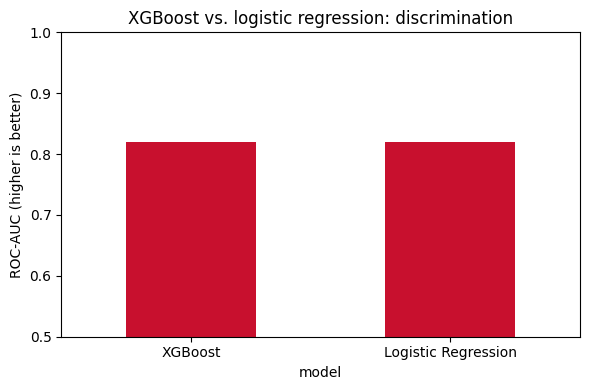

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
comparison[["roc_auc"]].plot(kind="bar", ax=ax, legend=False, color=["#c8102e", "#8c8c8c"])
ax.set_ylabel("ROC-AUC (higher is better)")
ax.set_title("XGBoost vs. logistic regression: discrimination")
ax.set_ylim(0.5, 1.0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Visualize

Using the XGBoost model's predictions:
  - the shot map shows *where* xG is highest;
  - the cumulative xG chart shows *when* each team generated their scoring chances over the
course of a game (temporal).

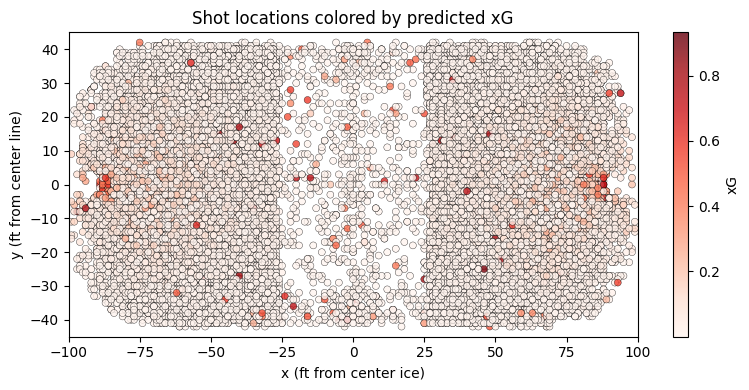

In [6]:
df["xg"] = xgb_pipeline.predict_proba(df[X_test.columns])[:, 1]

fig, ax = plt.subplots(figsize=(8, 4))
plot_shot_map(df, ax=ax)
plt.tight_layout()
plt.show()


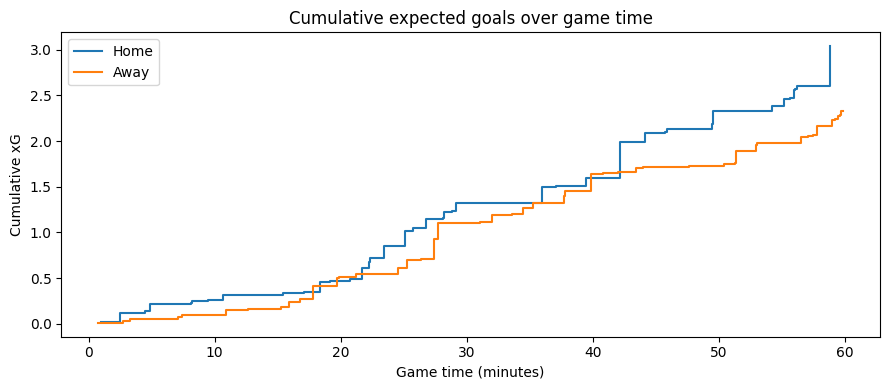

In [ ]:
# one game to show the cumulative xG race over time
example_game_id = df["game_id"].iloc[0]
game_df = df[df["game_id"] == example_game_id]

fig, ax = plt.subplots(figsize=(9, 4))
plot_cumulative_xg(game_df, ax=ax)
plt.tight_layout()
plt.show()


## 5. Finishing skill: who's scoring above or below what their shots deserve?

"Over/under-performer" analysis: for each player (and each team),
compare **actual goals** to **expected goals (xG)** summed across all their
shots. 

 - A player scoring well above their xG total is finishing better than
shot quality alone would predict (elite shooting talent, or a hot streak);
- Well below suggests the opposite (or a cold streak).

Using *out-of-fold* xG predictions.
 


In [8]:
df["xg_oof"] = compute_oof_xg(df, n_splits=5)
print("Out-of-fold xG computed for", len(df), "shots.")


Out-of-fold xG computed for 46898 shots.


In [9]:
player_table = player_finishing_skill(df, player_lookup, min_shots=30)

print("Top 10 over-performers (goals above expected, per 100 shots):")
display(player_table.head(10))

print("\nBottom 10 under-performers:")
display(player_table.tail(10))


Top 10 over-performers (goals above expected, per 100 shots):


,name,shots,goals,xg,goals_above_expected,goals_above_expected_per_100_shots
shooting_player_id,,,,,,
8477573,Nathan Walker,38,5,2.000368,2.999632,7.893769
8476438,Brandon Saad,46,8,4.425540,3.574460,7.770564
8477501,Valeri Nichushkin,39,6,3.075132,2.924868,7.499661
8476458,Ryan Strome,57,6,2.525273,3.474727,6.096013
8481014,Alexander Romanov,54,4,0.819285,3.180715,5.890213
8477456,J.T. Compher,56,7,3.760515,3.239485,5.784794
8479318,Auston Matthews,202,26,14.496869,11.503131,5.694619
8471709,Marc-Edouard Vlasic,60,5,1.630845,3.369155,5.615258
8482159,Tyson Foerster,79,9,4.807817,4.192183,5.306561



Bottom 10 under-performers:


,name,shots,goals,xg,goals_above_expected,goals_above_expected_per_100_shots
shooting_player_id,,,,,,
8477987,Ryan Donato,71,0,4.094951,-4.094951,-5.767537
8481147,Reese Johnson,34,0,1.973255,-1.973255,-5.803692
8479390,Taylor Raddysh,74,0,4.349954,-4.349954,-5.878316
8481624,Ilya Mikheyev,83,0,4.888701,-4.888701,-5.890001
8480762,Eric Robinson,53,0,3.130086,-3.130086,-5.905823
8478401,Pavel Zacha,92,3,8.600176,-5.600176,-6.087148
8480855,Jack McBain,39,0,2.404804,-2.404804,-6.166165
8479941,Justin Danforth,42,0,2.855442,-2.855442,-6.798670
8476927,Teddy Blueger,68,0,4.836974,-4.836974,-7.113197


In [10]:
team_table = team_finishing_skill(df, team_lookup, min_shots=100)
print("Team finishing skill, best to worst:")
display(team_table)


Team finishing skill, best to worst:


,name,shots,goals,xg,goals_above_expected,goals_above_expected_per_100_shots
owner_team_id,,,,,,
17,DET,1315,85,68.178802,16.821198,1.279179
21,COL,1528,92,77.924957,14.075043,0.921142
24,ANA,1202,65,57.224903,7.775097,0.646847
10,TOR,1630,96,87.460457,8.539543,0.523898
19,STL,1206,67,61.092716,5.907284,0.489825
25,DAL,1744,95,87.552422,7.447578,0.427040
15,WSH,1356,72,66.602638,5.397362,0.398036
14,TBL,1450,85,79.348206,5.651794,0.389779
54,VGK,1331,69,64.656532,4.343468,0.326331
